#### Performing Exploratory Data Analysis (EDA) to explore and understand the dataset.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Folder path:
folder_path = 'archive'

# List to hold all dataframes
dfs = []

# Looping through all files in the folder:
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        df = df.dropna() 
        dfs.append(df)


merged_df = pd.concat(dfs, axis=0, join='outer')


merged_df.reset_index(drop=True, inplace=True)

# Displaying or save the merged dataframe:
merged_df.head()

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,Unnamed: 0
0,Skybags Treble-FIFA 68cm Printed Polycarbonate...,bags & luggage,Suitcases & Trolley Bags,https://m.media-amazon.com/images/I/71C5GfgxW2...,https://www.amazon.in/Skybags-Treble-FIFA-Prin...,4.5,2,"₹7,250","₹14,500",NaN
1,Tommy Hilfiger Plastic Hard 66 cms Luggage (89...,bags & luggage,Suitcases & Trolley Bags,https://m.media-amazon.com/images/I/41lIioNQ3N...,https://www.amazon.in/Tommy-Hilfiger-Luggage-8...,3.6,70,"₹6,399","₹7,999",NaN
2,Samsonite Polyester Hard 68 Cms Luggage- Suitc...,bags & luggage,Suitcases & Trolley Bags,https://m.media-amazon.com/images/I/71XSVc5fxg...,https://www.amazon.in/Samsonite-Polyester-Lugg...,4.0,5,"₹12,220","₹18,800",NaN
3,Skybags Polycarbonate Hard 21 Cms Suitcase(_Blue),bags & luggage,Suitcases & Trolley Bags,https://m.media-amazon.com/images/I/51euSZMWAn...,https://www.amazon.in/Skybags-Combo-Polycarbon...,4.4,66,"₹6,648","₹10,043.04",NaN
4,Skybags Game-ON FIFA 79cm Printed Polycarbonat...,bags & luggage,Suitcases & Trolley Bags,https://m.media-amazon.com/images/I/710caoNQ4X...,https://www.amazon.in/Skybags-Printed-Polycarb...,4.3,5,"₹6,850","₹17,400",NaN


In [2]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681360 entries, 0 to 681359
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   name            681360 non-null  object 
 1   main_category   681360 non-null  object 
 2   sub_category    681360 non-null  object 
 3   image           681360 non-null  object 
 4   link            681360 non-null  object 
 5   ratings         681360 non-null  object 
 6   no_of_ratings   681360 non-null  object 
 7   discount_price  681360 non-null  object 
 8   actual_price    681360 non-null  object 
 9   Unnamed: 0      340680 non-null  float64
dtypes: float64(1), object(9)
memory usage: 52.0+ MB


In [3]:
# Get the record at the 5th index
record = merged_df.iloc[5]

for attribute, value in record.items():
    print(f"{attribute}: {value}")

name: American Tourister Krypton Strolly 69Cm, Red Polycarbonate Expandable Hard Suitcase
main_category: bags & luggage
sub_category: Suitcases & Trolley Bags
image: https://m.media-amazon.com/images/I/61Q19URNH6L._AC_UL320_.jpg
link: https://www.amazon.in/American-tourister-Krypton-69cm-Red/dp/B09SLDT9GF/ref=sr_1_631?qid=1679218890&s=luggage&sr=1-631
ratings: 2.8
no_of_ratings: 2
discount_price: ₹5,798
actual_price: ₹12,500
Unnamed: 0: nan


In [4]:
categorical_cols = list(merged_df.select_dtypes(include=['object', 'category']).columns)
continuous_cols = list(merged_df.select_dtypes(exclude=['object', 'category']).columns)

In [5]:
print(f"Categorical Columns: {categorical_cols}")
print(f"Continuous Columns: {continuous_cols}")

Categorical Columns: ['name', 'main_category', 'sub_category', 'image', 'link', 'ratings', 'no_of_ratings', 'discount_price', 'actual_price']
Continuous Columns: ['Unnamed: 0']


In [6]:
merged_df.isnull().sum()

name                   0
main_category          0
sub_category           0
image                  0
link                   0
ratings                0
no_of_ratings          0
discount_price         0
actual_price           0
Unnamed: 0        340680
dtype: int64

In [7]:
# Drop the 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in merged_df.columns:
    merged_df.drop(columns=['Unnamed: 0'], inplace=True)

print(merged_df.isnull().sum())


name              0
main_category     0
sub_category      0
image             0
link              0
ratings           0
no_of_ratings     0
discount_price    0
actual_price      0
dtype: int64


In [8]:
# Summary statistics for numerical columns
print(merged_df[['ratings', 'no_of_ratings', 'discount_price', 'actual_price']].describe())

       ratings no_of_ratings discount_price actual_price
count   681360        681360         681360       681360
unique      87          7861          16706         9319
top        4.0             1           ₹499         ₹999
freq     65394         71784          26704        68542


In [9]:
# Remove dollar signs and commas, then convert to numeric
merged_df['actual_price'] = merged_df['actual_price'].replace('[\₹,]', '', regex=True).astype(float)
merged_df['discount_price'] = merged_df['discount_price'].replace('[\₹,]', '', regex=True).astype(float)

In [10]:
# Convert ratings to float
merged_df['ratings'] = pd.to_numeric(merged_df['ratings'], errors='coerce')

# Convert no_of_ratings to integer
merged_df['no_of_ratings'] = pd.to_numeric(merged_df['no_of_ratings'], errors='coerce').fillna(0).astype(int)

print(merged_df.dtypes)

name               object
main_category      object
sub_category       object
image              object
link               object
ratings           float64
no_of_ratings       int64
discount_price    float64
actual_price      float64
dtype: object


In [11]:

# Calculate discount percentage
merged_df['discount_percentage'] = ((merged_df['actual_price'] - merged_df['discount_price']) / merged_df['actual_price']) * 100

# Summary statistics of discounts
discount_stats = merged_df.groupby('main_category')['discount_percentage'].describe()
print(discount_stats)


                            count       mean        std       min        25%  \
main_category                                                                  
accessories              129380.0  57.555868  21.243057  0.001771  45.022511   
appliances                51946.0  39.698672  18.613737  0.004000  25.947187   
bags & luggage             8478.0  51.439542  17.089252  0.011112  43.633802   
beauty & health           13830.0  32.907345  21.282728  0.050125  15.021459   
car & motorbike           10526.0  46.354119  19.748750  0.034880  32.829545   
grocery & gourmet foods    4714.0  23.147062  17.766937  0.066667   8.928571   
home & kitchen            25320.0  47.745918  19.977301  0.050025  33.511170   
home, kitchen, pets          24.0  14.863161   5.410442  8.062433  10.006051   
industrial supplies        5344.0  41.458108  21.309888  0.001695  25.000000   
kids' fashion             11518.0  49.789917  19.866150  0.011112  37.146760   
men's clothing            74196.0  48.15

In [12]:
# Summary statistics for numerical columns
print(merged_df[['ratings', 'no_of_ratings', 'discount_price', 'actual_price']].describe())

             ratings  no_of_ratings  discount_price  actual_price
count  669926.000000  681360.000000    6.813600e+05  6.813600e+05
mean        3.814368      80.066417    1.791600e+03  3.253900e+04
std         0.754169     165.132520    6.428439e+03  1.696171e+07
min         1.000000       0.000000    8.000000e+00  1.000000e+01
25%         3.500000       2.000000    3.590000e+02  9.390000e+02
50%         3.900000      11.000000    5.990000e+02  1.499000e+03
75%         4.200000      64.000000    1.229000e+03  2.890000e+03
max         5.000000     999.000000    1.249990e+06  9.900000e+09


/var/folders/2d/vxq9c2q11033cwvkk9cz599h0000gn/T/ipykernel_30533/3848759813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


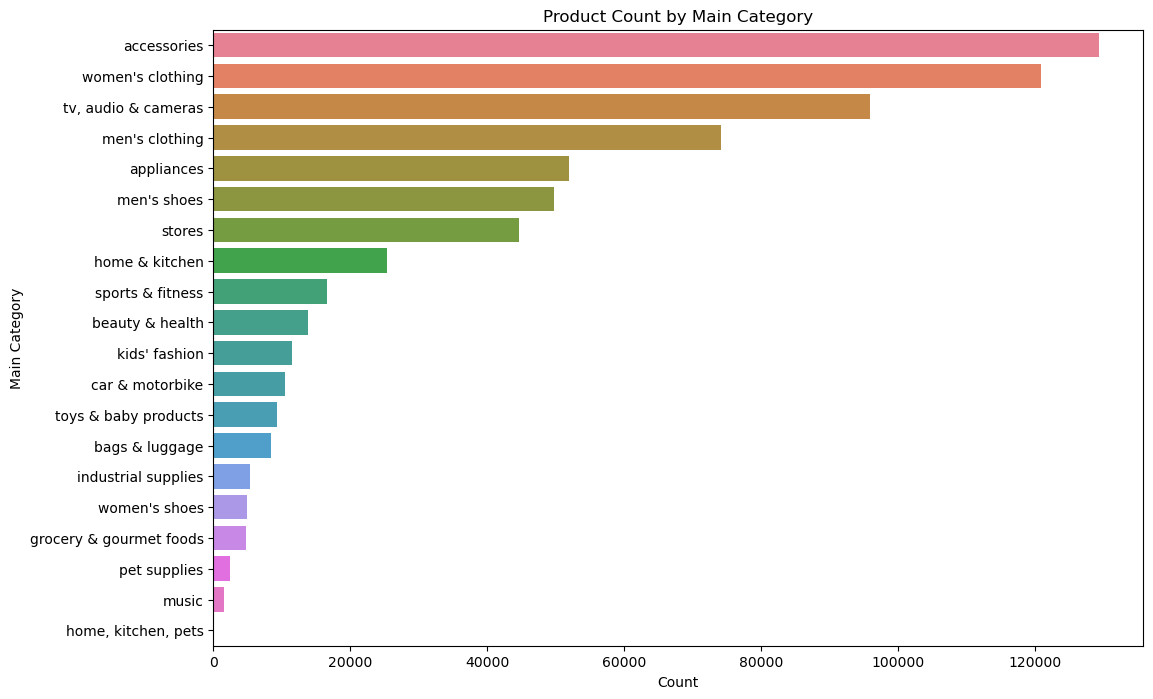

In [21]:
plt.figure(figsize=(12, 8))

# Get unique colors for each category
palette = sns.color_palette("husl", len(merged_df['main_category'].unique()))

sns.countplot(
    y='main_category', 
    data=merged_df, 
    order=merged_df['main_category'].value_counts().index,
    palette=palette
)

plt.title('Product Count by Main Category')
plt.xlabel('Count')
plt.ylabel('Main Category')
plt.show()


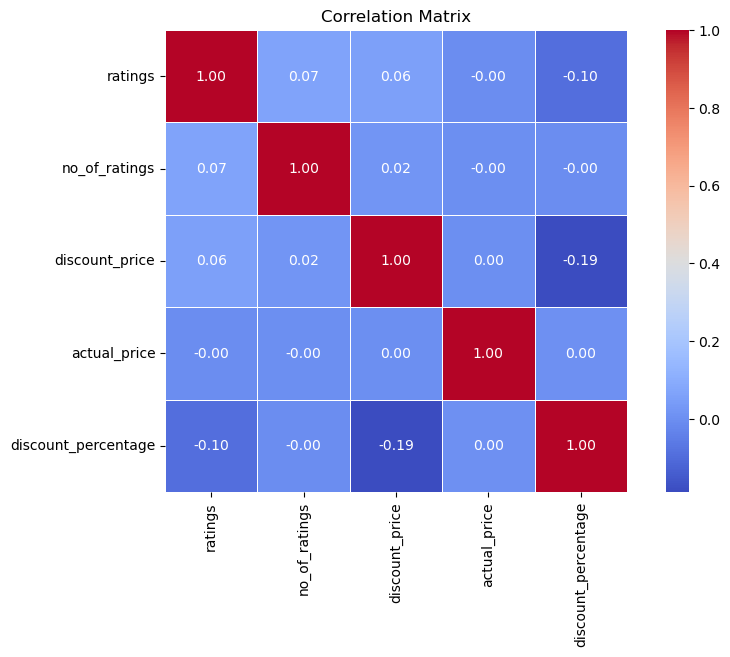

In [14]:

# Calculate correlation matrix
correlation_matrix = merged_df[['ratings', 'no_of_ratings', 'discount_price', 'actual_price', 'discount_percentage']].corr()

# Heatmap for correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=.5)
plt.title('Correlation Matrix')
plt.show()


In [15]:
# Top products by ratings
top_rated_products = merged_df.loc[merged_df.groupby('main_category')['ratings'].idxmax()][['name', 'main_category', 'ratings']]
print("\nTop Rated Products:")
print(top_rated_products)


Top Rated Products:
                                                     name  \
47877   Ameyes Blue Ocean Gradient Cat Eye Women sungl...   
61747   Samsung 236 L 2 Star Inverter Frost-Free Doubl...   
43      CAT Industrial Plate 35 Liter ABS Black Cabin ...   
107943              Oshea Herbals BB Cream 000 Light Warm   
46799   SHOPOFLUX Leather Key Cover Compatible with Ta...   
3409    Chaizup Instant Premix Ginger Tea | Karak Chai...   
2572    KRISHTAL TRADING Unbreakable Water Bottle 1 Li...   
476698  (Renewed) Usha Mist Air ICY 400MM Wall Fan wit...   
110946  CANWAY Flexible Fan Cleaning Duster for Multi-...   
5224    IZU.. Digital Watch for Boys & Girls Waterproo...   
25849   Levi's Men's 066 Active Brief with Smartskin T...   
34528                     crocs Unisex-Adult Classic Clog   
474298  ZEPAD 1404 Speaker Karaoke Machine Speaker WS-...   
122021  HUDACRUSH Dog Bath Brush Body Scrubber Shampoo...   
4141    YS, Women Cotton Padded Wire Free Sports Bra F...   
674

In [16]:
# Average ratings by category
average_ratings = merged_df.groupby('main_category')['ratings'].mean().sort_values(ascending=False)
print("\nAverage Ratings by Category:")
print(average_ratings)



Average Ratings by Category:
main_category
grocery & gourmet foods    4.059496
toys & baby products       4.012263
pet supplies               4.009334
beauty & health            3.985691
home & kitchen             3.974760
music                      3.928877
bags & luggage             3.898101
accessories                3.893068
stores                     3.863711
appliances                 3.843524
kids' fashion              3.834223
industrial supplies        3.820833
tv, audio & cameras        3.817645
sports & fitness           3.795765
women's clothing           3.754719
men's clothing             3.751430
car & motorbike            3.719957
women's shoes              3.654908
men's shoes                3.599170
home, kitchen, pets        3.408333
Name: ratings, dtype: float64


In [17]:
# Most discounted products
most_discounted_products = merged_df.nlargest(10, 'discount_percentage')[['name', 'main_category', 'discount_percentage']]
print("\nMost Discounted Products:")
print(most_discounted_products)



Most Discounted Products:
                                                     name     main_category  \
144869  Marutivilla Insect Killer, Mosquito Killer Lig...    home & kitchen   
357588  Marutivilla Insect Killer, Mosquito Killer Lig...    home & kitchen   
4445    Clovia Women's Activewear Ankle Length Printed...  sports & fitness   
477902  Clovia Women's Activewear Ankle Length Printed...  sports & fitness   
156063                              Amazon Pay eGift Card    bags & luggage   
261858                              Amazon Pay eGift Card       accessories   
530852                              Amazon Pay eGift Card    bags & luggage   
633188                              Amazon Pay eGift Card       accessories   
127821  IONIX ro pipe 10 Meters length, Ro tubing 1/4 ...        appliances   
140198  IONIX ro pipe 10 Meters length, Ro tubing 1/4 ...        appliances   

        discount_percentage  
144869            99.999994  
357588            99.999994  
4445         

In [18]:
# Average discount percentage by category
average_discount_percentage = merged_df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False)
print("\nAverage Discount Percentage by Category:")
print(average_discount_percentage)


Average Discount Percentage by Category:
main_category
women's clothing           59.971139
accessories                57.555868
stores                     52.325508
bags & luggage             51.439542
kids' fashion              49.789917
tv, audio & cameras        49.539656
men's clothing             48.158456
sports & fitness           48.107794
home & kitchen             47.745918
car & motorbike            46.354119
women's shoes              45.509907
men's shoes                44.440859
industrial supplies        41.458108
appliances                 39.698672
toys & baby products       39.357470
music                      38.880003
pet supplies               35.552109
beauty & health            32.907345
grocery & gourmet foods    23.147062
home, kitchen, pets        14.863161
Name: discount_percentage, dtype: float64


In [19]:
# Set display option for floats to prevent scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

# Price range by category
price_range = merged_df.groupby('main_category')['actual_price'].agg(['min', 'max'])
print("\nPrice Range by Category:")
print(price_range)



Price Range by Category:
                            min           max
main_category                                
accessories               30.00     700300.00
appliances                60.00     316990.00
bags & luggage            80.00     190000.00
beauty & health           10.00      87326.00
car & motorbike           63.00     104757.00
grocery & gourmet foods   10.00      38000.00
home & kitchen            30.00 9899999999.00
home, kitchen, pets     1499.00       9290.00
industrial supplies       59.00     160952.00
kids' fashion             99.00     123719.00
men's clothing           100.00      22956.00
men's shoes               39.00      39900.00
music                     60.00     122440.00
pet supplies              40.00      25890.00
sports & fitness          95.00   61082990.00
stores                    33.00     123719.00
toys & baby products      15.00      55200.00
tv, audio & cameras       30.00    1594900.00
women's clothing          99.00      21999.00
women's 

In [20]:
# Count of products per category
product_count = merged_df['main_category'].value_counts()
print("\nCount of Products per Category:")
print(product_count)


Count of Products per Category:
main_category
accessories                129380
women's clothing           120906
tv, audio & cameras         95914
men's clothing              74196
appliances                  51946
men's shoes                 49790
stores                      44602
home & kitchen              25320
sports & fitness            16642
beauty & health             13830
kids' fashion               11518
car & motorbike             10526
toys & baby products         9296
bags & luggage               8478
industrial supplies          5344
women's shoes                4914
grocery & gourmet foods      4714
pet supplies                 2502
music                        1518
home, kitchen, pets            24
Name: count, dtype: int64
